# Assignment 2: Variational Autoencoders for Remote Sensing


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyper-parameters
image_size = 64
h_dim = 128
z_dim = 32
num_epochs = 50
batch_size = 64
learning_rate = 1e-3


Using device: cpu


In [7]:
# Dataset Preparation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

# Downloading EuroSAT
dataset_dir = './data'
print("Loading EuroSAT dataset...")
try:
    dataset = datasets.EuroSAT(root=dataset_dir, download=True, transform=transform)
except Exception as e:
    print(f"Error downloading EuroSAT via torchvision: {e}")
    print("Falling back to downloading via wget...")
    import urllib.request
    import zipfile
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
    os.makedirs(dataset_dir, exist_ok=True)
    zip_path = os.path.join(dataset_dir, "EuroSAT.zip")
    if not os.path.exists(zip_path):
        urllib.request.urlretrieve(url, zip_path)
    if not os.path.exists(os.path.join(dataset_dir, "2750")):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_dir)
    dataset = datasets.ImageFolder(root=os.path.join(dataset_dir, "2750"), transform=transform)

data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
print(f"Dataset Size: {len(dataset)}")
print(f"Classes: {dataset.classes}")


Loading EuroSAT dataset...
Dataset Size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Task 1: Architectural Design


In [8]:
# VAE Architecture
class VAE(nn.Module):
    def __init__(self, image_channels=3, h_dim=128, z_dim=32):
        super(VAE, self).__init__()
        
        # Encoder (Convolutional)
        self.encoder = nn.Sequential(
            nn.Conv2d(image_channels, 32, kernel_size=4, stride=2, padding=1), # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),             # 32x32 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),            # 16x16 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),           # 8x8 -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten()                                                       # 256 * 4 * 4 = 4096
        )
        
        self.fc_mean = nn.Linear(4096, z_dim)
        self.fc_logvar = nn.Linear(4096, z_dim)
        
        # Decoder (Transposed Convolutional)
        self.fc_decode = nn.Linear(z_dim, 4096)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 8x8 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 16x16 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, image_channels, kernel_size=4, stride=2, padding=1), # 32x32 -> 64x64
            nn.Sigmoid() # Output values between 0 and 1
        )
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mean(h), self.fc_logvar(h)
    
    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 256, 4, 4)
        return self.decoder(h)
    
    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        out = self.decode(z)
        return out, mean, log_var

model = VAE(image_channels=3, h_dim=h_dim, z_dim=z_dim).to(device)
print(model)


VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mean): Linear(in_features=4096, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), strid

## Task 2: Training and Loss Function


In [9]:
# Loss Function and Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def vae_loss(recon_x, x, mean, log_var):
    # Reconstruction Loss (MSE)
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    
    # Kullback-Leibler Divergence
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    
    return RECON + KLD, RECON, KLD


In [ ]:
# Training Loop
epoch_losses = []
epoch_recons = []
epoch_klds = []

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_recon = 0
    train_kld = 0
    
    for batch_idx, (x, _) in enumerate(data_loader):
        x = x.to(device)
        
        # Forward pass
        recon_x, mean, log_var = model(x)
        loss, recon, kld = vae_loss(recon_x, x, mean, log_var)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_recon += recon.item()
        train_kld += kld.item()
        
    avg_loss = train_loss / len(data_loader.dataset)
    avg_recon = train_recon / len(data_loader.dataset)
    avg_kld = train_kld / len(data_loader.dataset)
    
    epoch_losses.append(avg_loss)
    epoch_recons.append(avg_recon)
    epoch_klds.append(avg_kld)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f})")

# Plot Loss vs Epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), epoch_losses, marker='o', label='Total Loss', color='purple')
plt.plot(range(1, num_epochs+1), epoch_recons, marker='s', label='Reconstruction Loss', color='blue', alpha=0.6)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.savefig('training_curves.png')
plt.show()


Starting Training...
Epoch [1/100], Loss: 117.1180 (Recon: 102.9770, KLD: 14.1410)
Epoch [2/100], Loss: 91.2824 (Recon: 76.5913, KLD: 14.6911)
Epoch [3/100], Loss: 87.7216 (Recon: 72.5147, KLD: 15.2069)
Epoch [4/100], Loss: 86.4725 (Recon: 71.0430, KLD: 15.4295)
Epoch [5/100], Loss: 85.5694 (Recon: 70.0271, KLD: 15.5423)
Epoch [6/100], Loss: 83.9023 (Recon: 68.3343, KLD: 15.5681)
Epoch [7/100], Loss: 83.1485 (Recon: 67.5376, KLD: 15.6109)
Epoch [8/100], Loss: 82.6444 (Recon: 67.0925, KLD: 15.5520)
Epoch [9/100], Loss: 81.9810 (Recon: 66.4483, KLD: 15.5326)
Epoch [10/100], Loss: 81.1759 (Recon: 65.6213, KLD: 15.5546)
Epoch [11/100], Loss: 81.0508 (Recon: 65.4793, KLD: 15.5715)
Epoch [12/100], Loss: 80.8350 (Recon: 65.2636, KLD: 15.5715)
Epoch [13/100], Loss: 80.1631 (Recon: 64.5742, KLD: 15.5889)
Epoch [14/100], Loss: 79.4262 (Recon: 63.7911, KLD: 15.6352)
Epoch [15/100], Loss: 79.0276 (Recon: 63.4741, KLD: 15.5536)
Epoch [16/100], Loss: 78.6529 (Recon: 63.0514, KLD: 15.6015)
Epoch [17/

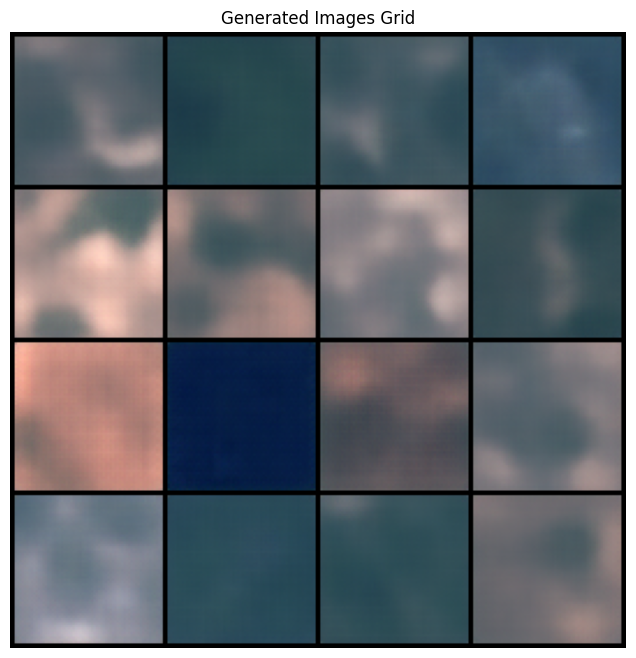

In [ ]:
# Generate Grid of 16 Samples
model.eval()
with torch.no_grad():
    # Sample from standard normal distribution
    z = torch.randn(16, z_dim).to(device)
    generated_images = model.decode(z).cpu()
    
    # Plot samples
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Generated Images Grid")
    plt.imshow(np.transpose(vutils.make_grid(generated_images, nrow=4, padding=2, normalize=True), (1, 2, 0)))
    plt.savefig('generated_samples.png')
    plt.show()


## Task 3: Latent Space Interpolation


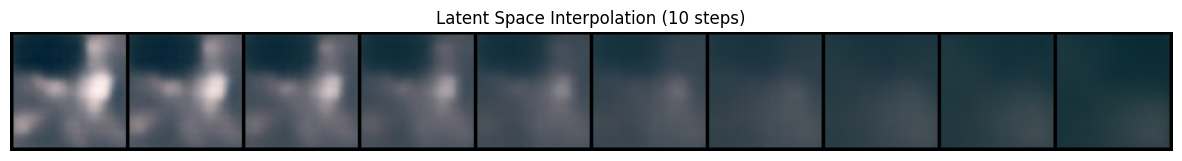

In [ ]:
# Find indices for two distinct classes, e.g., 'Industrial' and 'Pasture'
if hasattr(dataset, 'class_to_idx'):
    class_to_idx = dataset.class_to_idx
elif hasattr(dataset, 'classes'):
    class_to_idx = {dataset.classes[i]: i for i in range(len(dataset.classes))}
else:
    class_to_idx = {c: i for i, c in enumerate(os.listdir(os.path.join(dataset_dir, "2750")))}

industrial_idx = class_to_idx.get('Industrial')
pasture_idx = class_to_idx.get('Pasture')

img_industrial = None
img_pasture = None

for img, label in dataset:
    if label == industrial_idx and img_industrial is None:
        img_industrial = img
    elif label == pasture_idx and img_pasture is None:
        img_pasture = img
    if img_industrial is not None and img_pasture is not None:
        break

if img_industrial is None or img_pasture is None:
    print("Distinct classes not found, using first two images")
    img_industrial, _ = dataset[0]
    img_pasture, _ = dataset[len(dataset)//2]
    
# Encode and interpolate
model.eval()
with torch.no_grad():
    x1 = img_industrial.unsqueeze(0).to(device)
    x2 = img_pasture.unsqueeze(0).to(device)
    
    z1, _ = model.encode(x1)
    z2, _ = model.encode(x2)

    # Linear Interpolation
    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)
    z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas]).squeeze(1)
    
    # Decode interpolated vectors
    decoded_interp = model.decode(z_interp).cpu()

# Plot Interpolation
plt.figure(figsize=(15, 3))
plt.title("Latent Space Interpolation (10 steps)")
plt.axis("off")
plt.imshow(np.transpose(vutils.make_grid(decoded_interp, nrow=10, padding=2, normalize=True), (1, 2, 0)))
plt.savefig('interpolation.png')
plt.show()


## Task 4: Semantic Vector Arithmetic


Gathering samples...


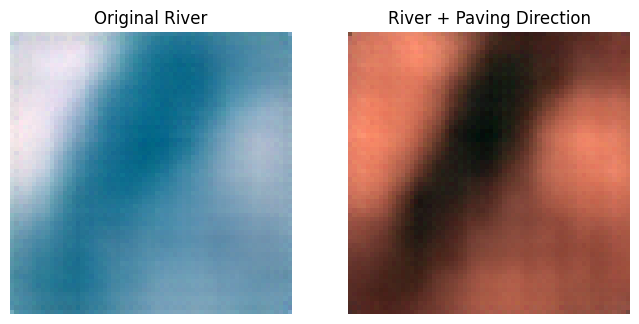

In [ ]:
# Semantic Arithmetic: River + (Highway - Forest)
forest_idx = class_to_idx.get('Forest')
highway_idx = class_to_idx.get('Highway')
river_idx = class_to_idx.get('River')

def get_class_images(class_idx, limit=100):
    imgs = []
    for img, label in dataset:
        if label == class_idx:
            imgs.append(img)
            if len(imgs) >= limit:
                break
    if not imgs:
        return None
    return torch.stack(imgs)

print("Gathering samples...")
forest_imgs = get_class_images(forest_idx, limit=128)
highway_imgs = get_class_images(highway_idx, limit=128)
river_imgs = get_class_images(river_idx, limit=1)

if forest_imgs is not None and highway_imgs is not None and river_imgs is not None:
    model.eval()
    with torch.no_grad():
        # Encode batches
        z_forest, _ = model.encode(forest_imgs.to(device))
        z_forest_avg = z_forest.mean(dim=0, keepdim=True)
        
        z_highway, _ = model.encode(highway_imgs.to(device))
        z_highway_avg = z_highway.mean(dim=0, keepdim=True)
        
        paving_direction = z_highway_avg - z_forest_avg
        
        # Vector Arithmetic
        x_river = river_imgs[0].unsqueeze(0).to(device)
        z_river, _ = model.encode(x_river)
        z_river_paved = z_river + paving_direction
        
        # Decode
        river_orig = model.decode(z_river).cpu()
        river_paved = model.decode(z_river_paved).cpu()

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(np.transpose(vutils.make_grid(river_orig, padding=2, normalize=True), (1, 2, 0)))
    ax[0].set_title("Original River")
    ax[0].axis("off")

    ax[1].imshow(np.transpose(vutils.make_grid(river_paved, padding=2, normalize=True), (1, 2, 0)))
    ax[1].set_title("River + Paving Direction")
    ax[1].axis("off")

    plt.savefig('semantic_arithmetic.png')
    plt.show()
else:
    print("Could not find required classes for semantic arithmetic.")
